PYNQ-Z2 FM RADIO - SYNTHETIC FM TEST

Overlay       : ./../hong/base.bit
Input Fs      : 1920000
Input samples : 1536000
Output samples: 38400
Audio tone    : 1000
FM deviation  : 75000

[1/10] Generating synthetic FM...
Generated 1536000 complex samples

[2/10] Packing I/Q data...
Packed samples: 1536000
Packed dtype: uint16

First 10 I:
[127 126 126 126 126 126 126 126 126 126]

First 10 Q:
[0 0 0 0 1 1 2 2 3 4]

First 10 packed words:
[ 127  126  126  126  382  382  638  638  894 1150]

[3/10] Plotting generated I/Q...


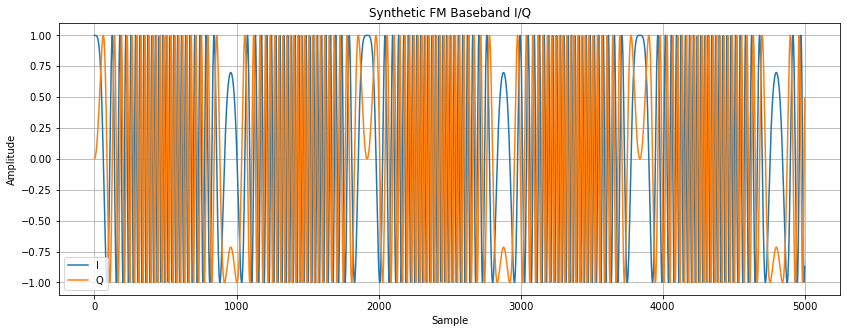

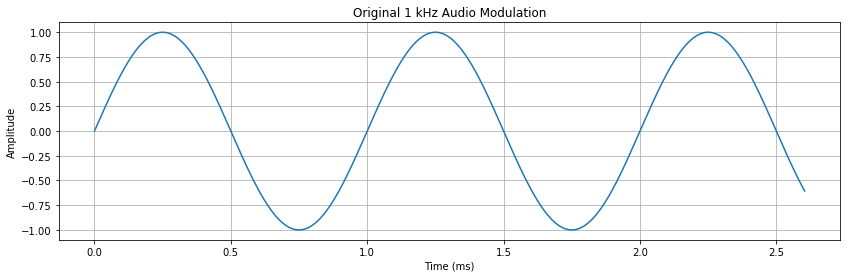


[4/10] Loading FPGA overlay...
Overlay: ./../hong/base.bit
Overlay loaded successfully.

[5/10] FPGA IP blocks:
   axi_dma_0
   ps7_0

[6/10] Getting AXI DMA...

[7/10] Allocating DDR buffers...


/usr/local/share/pynq-venv/lib/python3.8/site-packages/pynq/overlay.py:681: UserWarning: Interrupt s2mm_introut not created: Could not find UIO device for interrupt pin for IRQ number 62
  warnings.warn('Interrupt {} not created: {}'.format(


Input buffer address : 0x16c00000
Output buffer address: 0x16880000

[8/10] Copying synthetic FM into DDR...
Input DDR ready.

Starting S2MM...
Starting MM2S...
DMA started.

[9/10] Waiting for DMA...
DMA completed.

[10/10] Processing FPGA output...

FPGA OUTPUT
Samples: 38400
Min: -0.99472046
Max: 0.99157715
RMS: 0.7632185


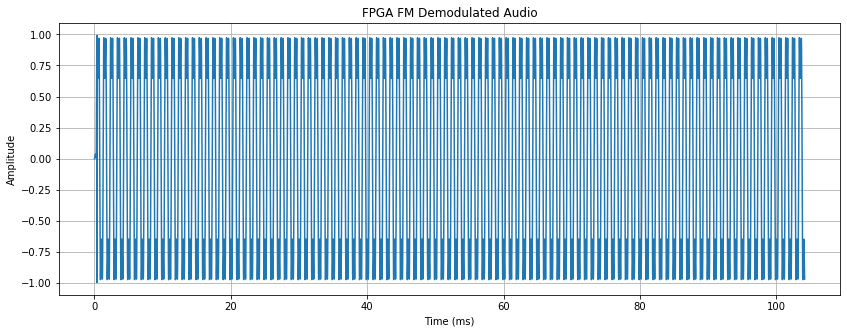

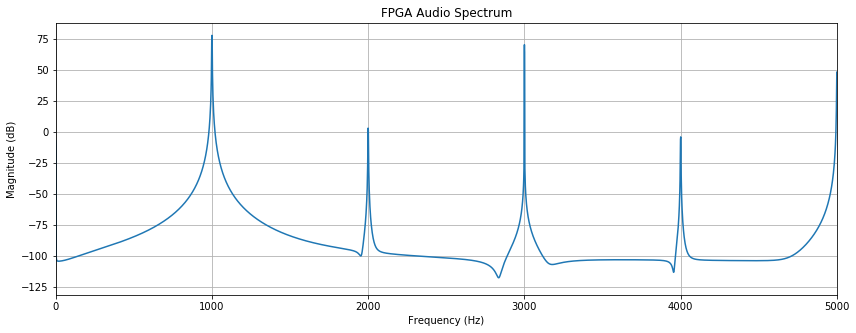


RESULT
Expected frequency : 1000 Hz
Detected frequency : 1000.48828125 Hz
Error              : 0.48828125 Hz

FPGA audio:



Saved:
  synthetic_fm_input.npy
  fpga_audio_output.npy

TEST COMPLETE


In [1]:
# ============================================================
# PYNQ-Z2 FM RADIO TEST
# Synthetic FM I/Q -> DDR -> AXI DMA -> FPGA -> Audio
#
# SINGLE JUPYTER CELL
# ============================================================


# ============================================================
# USER CONFIGURATION
# ============================================================

# เปลี่ยน overlay ตรงนี้บรรทัดเดียว
# OVERLAY_PATH = "./../vivado/pynq_fm.bit"
OVERLAY_PATH = "./../hong/base.bit"


# ============================================================
# FM TEST CONFIGURATION
# ============================================================

INPUT_SAMPLE_RATE = 1_920_000     # 1.92 MHz
AUDIO_FREQUENCY = 1_000           # 1 kHz test tone
FM_DEVIATION = 75_000             # 75 kHz

AUDIO_SAMPLE_RATE = 48_000

# Original notebook:
# len_out = len_in / 40

LEN_IN = 1024 * 1500
LEN_OUT = LEN_IN // 40


# ============================================================
# IMPORTS
# ============================================================

import time
import numpy as np
import matplotlib.pyplot as plt

from pynq import Overlay, allocate
from IPython.display import Audio, display


# ============================================================
# START
# ============================================================

print("=" * 70)
print("PYNQ-Z2 FM RADIO - SYNTHETIC FM TEST")
print("=" * 70)

print()
print("Overlay       :", OVERLAY_PATH)
print("Input Fs      :", INPUT_SAMPLE_RATE)
print("Input samples :", LEN_IN)
print("Output samples:", LEN_OUT)
print("Audio tone    :", AUDIO_FREQUENCY)
print("FM deviation  :", FM_DEVIATION)

print("=" * 70)


# ============================================================
# 1. GENERATE SYNTHETIC FM
# ============================================================

print()
print("[1/10] Generating synthetic FM...")


n = np.arange(
    LEN_IN,
    dtype=np.float64
)

t = n / INPUT_SAMPLE_RATE


# ------------------------------------------------------------
# Audio modulation signal
# ------------------------------------------------------------

audio_modulation = np.sin(
    2.0
    * np.pi
    * AUDIO_FREQUENCY
    * t
)


# ------------------------------------------------------------
# FM phase
#
# instantaneous frequency:
#
#   f(t) = FM_DEVIATION * audio(t)
#
# phase increment:
#
#   dphi = 2*pi*f(t)/Fs
# ------------------------------------------------------------

phase_increment = (
    2.0
    * np.pi
    * FM_DEVIATION
    * audio_modulation
    / INPUT_SAMPLE_RATE
)


fm_phase = np.cumsum(
    phase_increment
)


# ------------------------------------------------------------
# Complex baseband I/Q
# ------------------------------------------------------------

complex_samples = np.exp(
    1j * fm_phase
)


print(
    "Generated",
    len(complex_samples),
    "complex samples"
)


# ============================================================
# 2. CONVERT TO RTL-SDR I/Q FORMAT
# ============================================================

print()
print("[2/10] Packing I/Q data...")


# RTL-SDR style:
#
#   I = -127 ... +127
#   Q = -127 ... +127
#
# stored as int8


i_data = (
    complex_samples.real * 127.0
).astype(np.int8)


q_data = (
    complex_samples.imag * 127.0
).astype(np.int8)


# ------------------------------------------------------------
# Interleave:
#
#   I Q I Q I Q ...
# ------------------------------------------------------------

iq_interleaved = np.empty(
    LEN_IN * 2,
    dtype=np.int8
)


iq_interleaved[0::2] = i_data
iq_interleaved[1::2] = q_data


# ------------------------------------------------------------
# Pack two int8 into one uint16
# ------------------------------------------------------------

packed_samples = iq_interleaved.view(
    np.uint16
)


print(
    "Packed samples:",
    len(packed_samples)
)

print(
    "Packed dtype:",
    packed_samples.dtype
)

print()
print("First 10 I:")
print(i_data[:10])

print()
print("First 10 Q:")
print(q_data[:10])

print()
print("First 10 packed words:")
print(packed_samples[:10])


# ============================================================
# 3. PLOT GENERATED I/Q
# ============================================================

print()
print("[3/10] Plotting generated I/Q...")


plot_len = min(
    5000,
    LEN_IN
)


plt.figure(
    figsize=(14, 5)
)

plt.plot(
    complex_samples.real[:plot_len],
    label="I"
)

plt.plot(
    complex_samples.imag[:plot_len],
    label="Q"
)

plt.title(
    "Synthetic FM Baseband I/Q"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.grid()
plt.legend()

plt.show()


# ============================================================
# 4. PLOT ORIGINAL AUDIO MODULATION
# ============================================================

plt.figure(
    figsize=(14, 4)
)

plt.plot(
    t[:plot_len] * 1000.0,
    audio_modulation[:plot_len]
)

plt.title(
    "Original 1 kHz Audio Modulation"
)

plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")

plt.grid()

plt.show()


# ============================================================
# 5. LOAD FPGA OVERLAY
# ============================================================

print()
print("[4/10] Loading FPGA overlay...")

print(
    "Overlay:",
    OVERLAY_PATH
)


ol = Overlay(
    OVERLAY_PATH
)


print("Overlay loaded successfully.")


# ============================================================
# 6. DISPLAY AVAILABLE IP
# ============================================================

print()
print("[5/10] FPGA IP blocks:")

for ip_name in ol.ip_dict.keys():
    print(
        "  ",
        ip_name
    )


# ============================================================
# 7. GET AXI DMA
# ============================================================

print()
print("[6/10] Getting AXI DMA...")


dma = ol.axi_dma_0


print(dma)


# ============================================================
# 8. ALLOCATE DDR BUFFERS
# ============================================================

print()
print("[7/10] Allocating DDR buffers...")


input_buffer = allocate(
    shape=(LEN_IN,),
    dtype=np.uint16
)


output_buffer = allocate(
    shape=(LEN_OUT,),
    dtype=np.int16
)


print(
    "Input buffer address :",
    hex(input_buffer.device_address)
)

print(
    "Output buffer address:",
    hex(output_buffer.device_address)
)


# ============================================================
# 9. COPY DATA + DMA
# ============================================================

print()
print("[8/10] Copying synthetic FM into DDR...")


np.copyto(
    input_buffer,
    packed_samples
)


print("Input DDR ready.")


# ------------------------------------------------------------
# Start S2MM first
# ------------------------------------------------------------

print()
print("Starting S2MM...")


dma.recvchannel.transfer(
    output_buffer
)


# ------------------------------------------------------------
# Start MM2S
# ------------------------------------------------------------

print("Starting MM2S...")


dma.sendchannel.transfer(
    input_buffer
)


print("DMA started.")


# ============================================================
# 10. WAIT FOR DMA
# ============================================================

print()
print("[9/10] Waiting for DMA...")


timeout_sec = 10.0

start_time = time.time()


while True:

    send_idle = dma.sendchannel.idle
    recv_idle = dma.recvchannel.idle

    if send_idle and recv_idle:
        break

    if (
        time.time()
        - start_time
        > timeout_sec
    ):

        print()
        print("DMA TIMEOUT")
        print()

        print(
            dma.register_map
        )

        raise RuntimeError(
            "DMA timeout"
        )

    time.sleep(
        0.001
    )


print("DMA completed.")


# ============================================================
# 11. CONVERT FPGA OUTPUT
# ============================================================

print()
print("[10/10] Processing FPGA output...")


fpga_audio = (
    output_buffer.astype(
        np.float32
    )
    / 32768.0
)


print()
print("=" * 70)
print("FPGA OUTPUT")
print("=" * 70)

print(
    "Samples:",
    len(fpga_audio)
)

print(
    "Min:",
    fpga_audio.min()
)

print(
    "Max:",
    fpga_audio.max()
)

print(
    "RMS:",
    np.sqrt(
        np.mean(
            fpga_audio ** 2
        )
    )
)


# ============================================================
# 12. PLOT FPGA AUDIO
# ============================================================

audio_plot_len = min(
    5000,
    len(fpga_audio)
)


audio_time = (
    np.arange(audio_plot_len)
    / AUDIO_SAMPLE_RATE
)


plt.figure(
    figsize=(14, 5)
)

plt.plot(
    audio_time * 1000.0,
    fpga_audio[:audio_plot_len]
)

plt.title(
    "FPGA FM Demodulated Audio"
)

plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")

plt.grid()

plt.show()


# ============================================================
# 13. FFT
# ============================================================

fft_len = min(
    32768,
    len(fpga_audio)
)


fft_data = fpga_audio[
    :fft_len
]


fft_window = np.hanning(
    fft_len
)


fft_result = np.fft.rfft(
    fft_data * fft_window
)


fft_frequency = np.fft.rfftfreq(
    fft_len,
    1.0 / AUDIO_SAMPLE_RATE
)


fft_magnitude = np.abs(
    fft_result
)


fft_db = (
    20.0
    * np.log10(
        fft_magnitude
        + 1e-12
    )
)


plt.figure(
    figsize=(14, 5)
)

plt.plot(
    fft_frequency,
    fft_db
)

plt.xlim(
    0,
    5000
)

plt.title(
    "FPGA Audio Spectrum"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")

plt.grid()

plt.show()


# ============================================================
# 14. FIND AUDIO PEAK
# ============================================================

peak_index = (
    np.argmax(
        fft_magnitude[1:]
    )
    + 1
)


detected_frequency = (
    fft_frequency[
        peak_index
    ]
)


print()
print("=" * 70)
print("RESULT")
print("=" * 70)

print(
    "Expected frequency :",
    AUDIO_FREQUENCY,
    "Hz"
)

print(
    "Detected frequency :",
    detected_frequency,
    "Hz"
)

print(
    "Error              :",
    detected_frequency
    - AUDIO_FREQUENCY,
    "Hz"
)

print("=" * 70)


# ============================================================
# 15. PLAY AUDIO
# ============================================================

print()
print("FPGA audio:")

display(
    Audio(
        fpga_audio,
        rate=AUDIO_SAMPLE_RATE,
        autoplay=False
    )
)


# ============================================================
# 16. SAVE DATA
# ============================================================

np.save(
    "synthetic_fm_input.npy",
    complex_samples
)

np.save(
    "fpga_audio_output.npy",
    fpga_audio
)


print()
print("Saved:")
print(
    "  synthetic_fm_input.npy"
)

print(
    "  fpga_audio_output.npy"
)


# ============================================================
# DONE
# ============================================================

print()
print("=" * 70)
print("TEST COMPLETE")
print("=" * 70)